# <center><strong> Bike Rental Analysis & Prediction </strong></center>
-------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

---------------------------

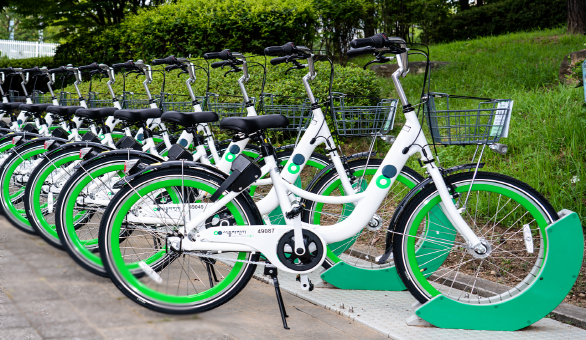

In [71]:
from IPython.display import Image
Image(filename='bi.png')

------------------------------

## <center><strong> Project Overview </strong></center>

#### **Bike share systems are a way to rent bikes where the process of obtaining membership, renting and returning bikes is automated through a network of kiosks located throughout the city. Through these systems, people can rent a bike from one location and return it to another location based on their needs. Currently, there are more than 500 bike share programs around the world.**

---------------------------------
---------------------------------
---------------------------------

## **Import Libraries** 

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from datetime import datetime
import calendar 
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt
from pickle import dump, load

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

----------------------------
### **Initial fonction**
------------------------------

In [73]:
def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.xlabel('Year')
    plt.show()

def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

def boxplot(data, col):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(8, 4)
    sns.boxplot(data=data,x=col,orient="o",ax=axes)
    plt.show()

def boxplot2(data, x,y):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(10, 5)
    sns.boxplot(data=data,y=y,x=x,orient="v",ax=axes)
    plt.show()

----------------------------------
----------------------------------

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

----------------------

In [74]:
df = pd.read_csv("Bike rental dataset.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [75]:
df.shape

(10886, 12)

In [76]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [77]:
df.rename(columns={'casual': 'non-subscribed_users', 
                   'registered':'subscribed_users', 
                   'count': 'count_of_users', 
                   'temp':'Actual_Temperature', 
                   'atemp':'Feels_Like_Temperature'} ,inplace=True)

In [78]:
df

,datetime,season,holiday,workingday,weather,Actual_Temperature,Feels_Like_Temperature,humidity,windspeed,non-subscribed_users,subscribed_users,count_of_users
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   datetime                10886 non-null  object 
 1   season                  10886 non-null  int64  
 2   holiday                 10886 non-null  int64  
 3   workingday              10886 non-null  int64  
 4   weather                 10886 non-null  int64  
 5   Actual_Temperature      10886 non-null  float64
 6   Feels_Like_Temperature  10886 non-null  float64
 7   humidity                10886 non-null  int64  
 8   windspeed               10886 non-null  float64
 9   non-subscribed_users    10886 non-null  int64  
 10  subscribed_users        10886 non-null  int64  
 11  count_of_users          10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [80]:
df.isnull().sum()

datetime                  0
season                    0
holiday                   0
workingday                0
weather                   0
Actual_Temperature        0
Feels_Like_Temperature    0
humidity                  0
windspeed                 0
non-subscribed_users      0
subscribed_users          0
count_of_users            0
dtype: int64

In [81]:
df.duplicated().sum()

0

-----------------------
-----------------------

### **Basic Statistical Overview**

---------------------------------

- #### Summary Statistical : **describe()**

In [82]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
Actual_Temperature,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
Feels_Like_Temperature,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
non-subscribed_users,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
subscribed_users,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


In [83]:
df.select_dtypes(include='object').describe()

,datetime
count,10886
unique,10886
top,2011-01-01 00:00:00
freq,1


-------------------------

## **Feature Extraction**

----------------------------

#### Extracting new column **[date]** from **[datetime]**

In [84]:
"2011-01-01 00:00:00".split()

['2011-01-01', '00:00:00']

In [85]:
df['datetime'][0].split()

['2011-01-01', '00:00:00']

In [86]:
df['datetime'][0].split()[0]

'2011-01-01'

In [87]:
df["date"] = df['datetime'].apply(lambda x : x.split()[0])

In [88]:
df['date'].head()

0    2011-01-01
1    2011-01-01
2    2011-01-01
3    2011-01-01
4    2011-01-01
Name: date, dtype: object

--------------------

#### Extracting new column **[time]** from **[dateime]**

In [89]:
df['datetime'][0].split()

['2011-01-01', '00:00:00']

In [90]:
df['datetime'][0].split()[1]

'00:00:00'

In [91]:
df['time'] = df['datetime'].apply(lambda x : x.split()[1])

In [92]:
df['time'].head()

0    00:00:00
1    01:00:00
2    02:00:00
3    03:00:00
4    04:00:00
Name: time, dtype: object

-------------------------------------

#### Extracting new column **[year]** from **[date]**

In [93]:
df['date'][0].split()[0]

'2011-01-01'

In [94]:
df['date'][0].split()[0].split('-')[0]

'2011'

In [95]:
df['year'] =df['date'].apply(lambda x : x.split()[0].split('-')[0])

In [96]:
df['year'].value_counts()

year
2012    5464
2011    5422
Name: count, dtype: int64

C:\Users\RPC\AppData\Local\Temp\ipykernel_18392\1817585652.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, palette=['green','red'])


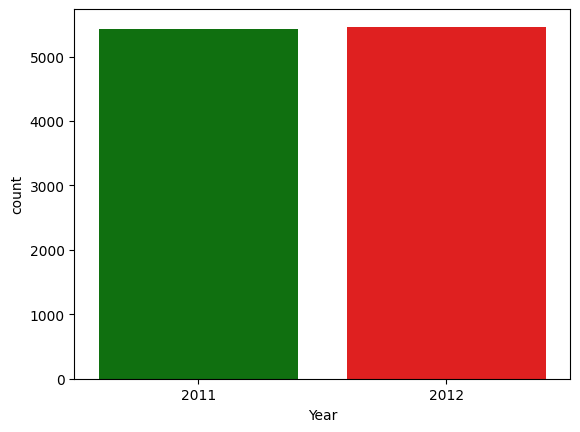

In [97]:
sns.countplot(x='year', data=df, palette=['green','red'])
plt.xlabel('Year')
plt.show()

-------------------------------

#### Extracting new column **[month]** from **[date]**

In [98]:
df['date'][0].split()[0]

'2011-01-01'

In [99]:
df['date'][0].split()[0].split('-')[1]

'01'

In [100]:
df['date'].apply(lambda x : calendar.month_name[datetime.strptime(x,"%Y-%m-%d").month])

0         January
1         January
2         January
3         January
4         January
           ...   
10881    December
10882    December
10883    December
10884    December
10885    December
Name: date, Length: 10886, dtype: object

In [101]:
df["month"] = df['date'].apply(lambda x : calendar.month_name[datetime.strptime(x,"%Y-%m-%d").month])

In [102]:
df['month'].head()

0    January
1    January
2    January
3    January
4    January
Name: month, dtype: object

In [103]:
df['month'].value_counts()

month
May          912
June         912
July         912
August       912
December     912
October      911
November     911
April        909
September    909
February     901
March        901
January      884
Name: count, dtype: int64

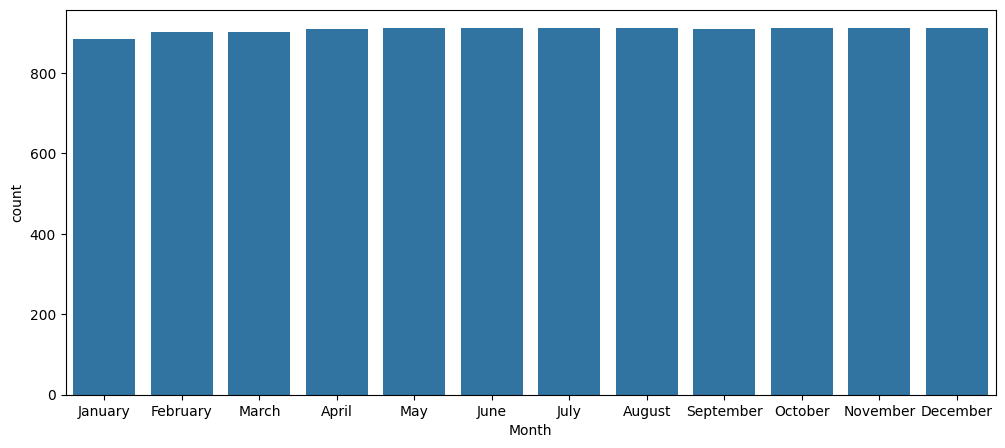

In [104]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='month', data=df)
plt.xlabel('Month')
plt.show()

------------------------

#### Extracting new column **[day]** from **[date]**

In [105]:
df['date'][0].split()[0]

'2011-01-01'

In [106]:
df['date'][0].split()[0].split('-')[2]

'01'

In [107]:
df['date'].apply(lambda x : calendar.day_name[datetime.strptime(x,"%Y-%m-%d").weekday()])

0         Saturday
1         Saturday
2         Saturday
3         Saturday
4         Saturday
           ...    
10881    Wednesday
10882    Wednesday
10883    Wednesday
10884    Wednesday
10885    Wednesday
Name: date, Length: 10886, dtype: object

In [108]:
df["day"] = df['date'].apply(lambda x : calendar.day_name[datetime.strptime(x,"%Y-%m-%d").weekday()])

In [109]:
df["day"].head()

0    Saturday
1    Saturday
2    Saturday
3    Saturday
4    Saturday
Name: day, dtype: object

In [110]:
df["day"].value_counts()

day
Saturday     1584
Sunday       1579
Thursday     1553
Monday       1551
Wednesday    1551
Tuesday      1539
Friday       1529
Name: count, dtype: int64

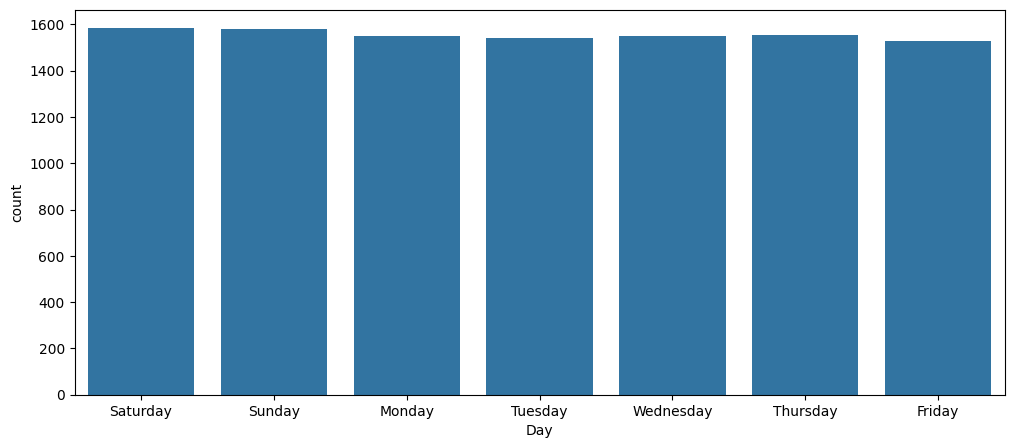

In [111]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='day', data=df)
plt.xlabel('Day')
plt.show()

------------------------

#### Extracting new column **[hour]** from **[time]**

In [112]:
df['time'][0]

'00:00:00'

In [113]:
df['time'][0].split(':')[0]

'00'

In [114]:
df['time'].apply(lambda x : x.split(":")[0])

0        00
1        01
2        02
3        03
4        04
         ..
10881    19
10882    20
10883    21
10884    22
10885    23
Name: time, Length: 10886, dtype: object

In [115]:
df["hour"] = df['time'].apply(lambda x : x.split(":")[0])

In [116]:
df['hour'].value_counts()

hour
12    456
13    456
22    456
21    456
20    456
19    456
18    456
17    456
16    456
15    456
14    456
23    456
11    455
10    455
09    455
08    455
07    455
06    455
00    455
01    454
05    452
02    448
04    442
03    433
Name: count, dtype: int64

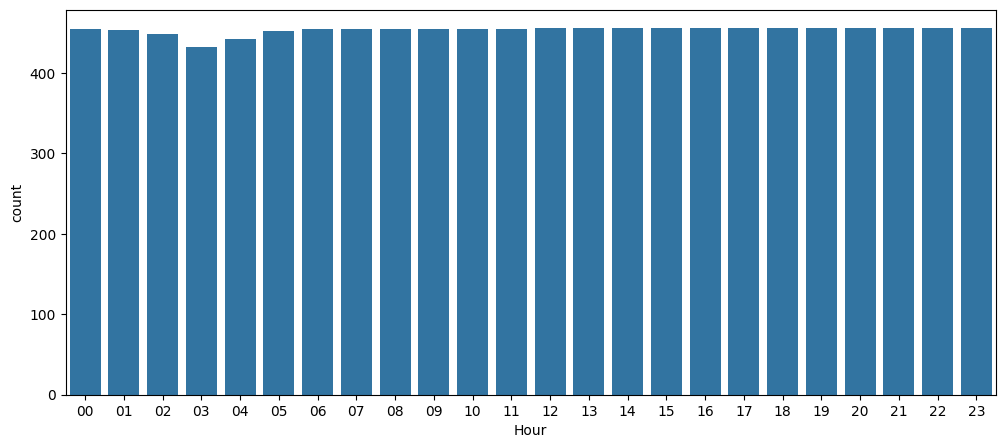

In [117]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='hour', data=df)
plt.xlabel('Hour')
plt.show()

------------------------

#### Extracting new column **[the_usual_time_periods_per_day]** from **[hour]**

In [118]:
df['hour'] = df['hour'].astype(int)

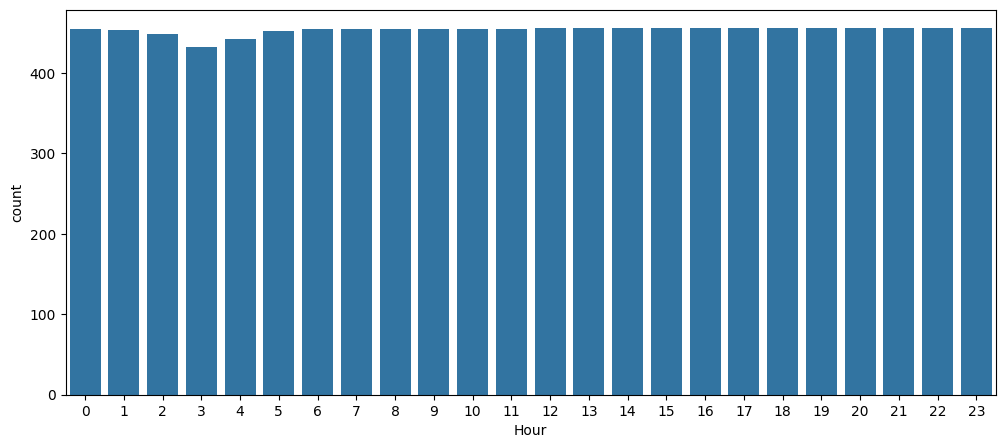

In [119]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='hour', data=df)
plt.xlabel('Hour')
plt.show()

In [120]:
def TheUsualTimePeriodsPerDay(hour):
    hour = int(hour)
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 13:
        return 'Midday/Noon'
    elif 14 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 20:
        return 'Evening'
    elif 21 <= hour <= 23:
        return 'Night'
    else: # 0 <= hour <= 5
        return 'Midnight and After'

df['the_usual_time_periods_per_day'] = df['hour'].apply(lambda x : TheUsualTimePeriodsPerDay(x))

In [121]:
df['the_usual_time_periods_per_day'].value_counts()

the_usual_time_periods_per_day
Morning               2730
Midnight and After    2684
Afternoon             1824
Evening               1368
Night                 1368
Midday/Noon            912
Name: count, dtype: int64

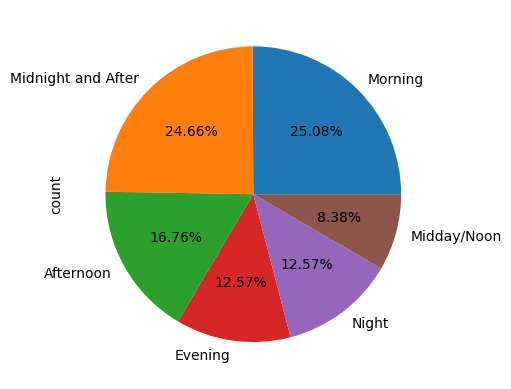

In [122]:
df['the_usual_time_periods_per_day'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

-----------------------

#### Extracting new column **[weather_feeling]** from **[Feels_Like_Temperature]**

In [123]:
df['Feels_Like_Temperature'].unique()

array([14.395, 13.635, 12.88 , 17.425, 19.695, 16.665, 21.21 , 22.725,
       21.97 , 20.455, 11.365, 10.605,  9.85 ,  8.335,  6.82 ,  5.305,
        6.06 ,  9.09 , 12.12 ,  7.575, 15.91 ,  3.03 ,  3.79 ,  4.545,
       15.15 , 18.18 , 25.   , 26.515, 27.275, 29.545, 23.485, 25.76 ,
       31.06 , 30.305, 24.24 , 18.94 , 31.82 , 32.575, 33.335, 28.79 ,
       34.85 , 35.605, 37.12 , 40.15 , 41.665, 40.91 , 39.395, 34.09 ,
       28.03 , 36.365, 37.88 , 42.425, 43.94 , 38.635,  1.515,  0.76 ,
        2.275, 43.18 , 44.695, 45.455])

In [124]:
def classify_temperature(FeelsLikeTemperature):
    
    if FeelsLikeTemperature < 0:
        return 'Freezing Cold'
    elif FeelsLikeTemperature < 11:
        return 'Cold'
    elif FeelsLikeTemperature < 21:
        return 'Cool'
    elif FeelsLikeTemperature < 26:
        return 'Mild'
    elif FeelsLikeTemperature < 31:
        return 'Warm'
    elif FeelsLikeTemperature < 36:
        return 'Hot'
    else:
        return 'Extremely Hot'

df['weather_feeling'] = df['Feels_Like_Temperature'].apply(lambda x : classify_temperature(x))

In [125]:
df['weather_feeling'].value_counts()

weather_feeling
Cool             3329
Mild             2375
Hot              2272
Warm             1539
Cold              743
Extremely Hot     628
Name: count, dtype: int64

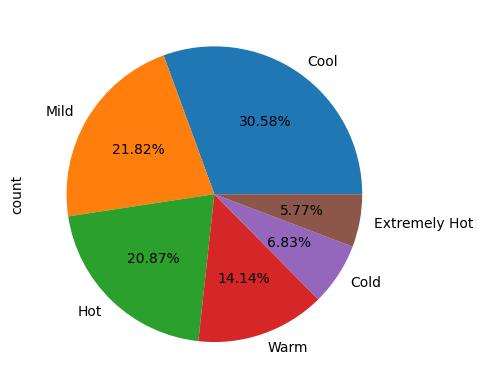

In [126]:
df['weather_feeling'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

------------------------

#### Mapping **season column**

In [127]:
df['season'].value_counts()

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

In [128]:
dictionnaire_saisons = {1 :"Winter" , 2: "Spring", 3 : "Summer", 4 : "Fall"}
df["season"] = df["season"].map(dictionnaire_saisons)


In [129]:
df['season'].value_counts()

season
Fall      2734
Spring    2733
Summer    2733
Winter    2686
Name: count, dtype: int64

C:\Users\RPC\AppData\Local\Temp\ipykernel_18392\3045485625.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='season', data=df, palette=['green','red','yellow','blue'])


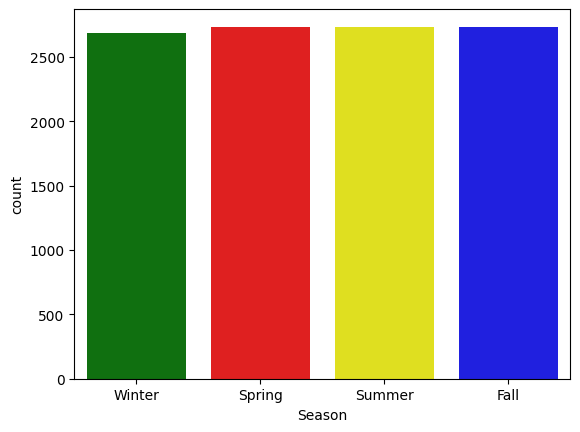

In [130]:
sns.countplot(x='season', data=df, palette=['green','red','yellow','blue'])
plt.xlabel('Season')
plt.show()

----------------------------------

#### Mapping **weather column**

##### Clear + Few clouds + Partly cloudy + Partly cloudy ----> **Clear to Partly Cloudy**
##### Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist ----> **Mist and Cloudy**
##### Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds" ----> **Light Precipitation**
##### Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog ----> **Severe Weather**

In [131]:
df["weather"].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

In [132]:
df["weather"] = df["weather"].map({1: "Clear to Partly Cloudy",\
                                        2 : "Mist and Cloudy", \
                                        3 : "Light Precipitation", \
                                        4 :"Severe Weather" })

C:\Users\RPC\AppData\Local\Temp\ipykernel_18392\1604790228.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather', data=df, palette=['green','red','yellow','blue'])


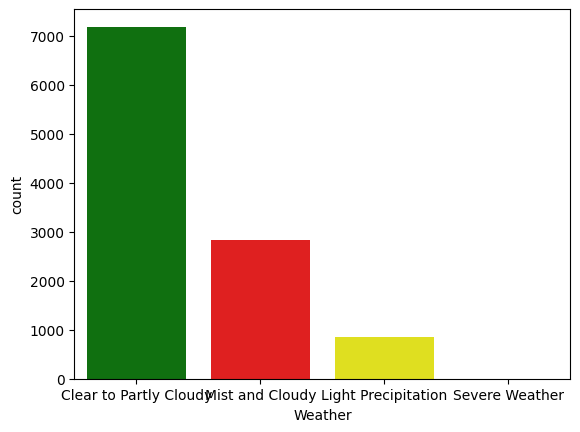

In [133]:
sns.countplot(x='weather', data=df, palette=['green','red','yellow','blue'])
plt.xlabel('Weather')
plt.show()

----------------------------------
#### Mapping **holiday column**

In [134]:
df["holiday"] = df["holiday"].map({0: "no", 1: "yes"})

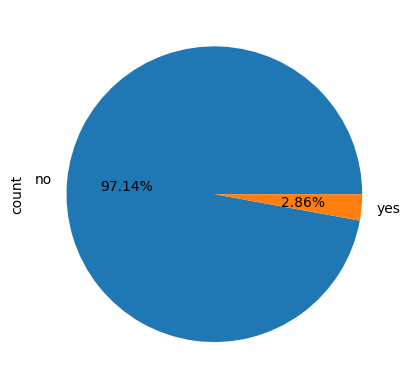

In [135]:
pie(df,'holiday')

------------------------------------
## **EDA**
------------------------------------

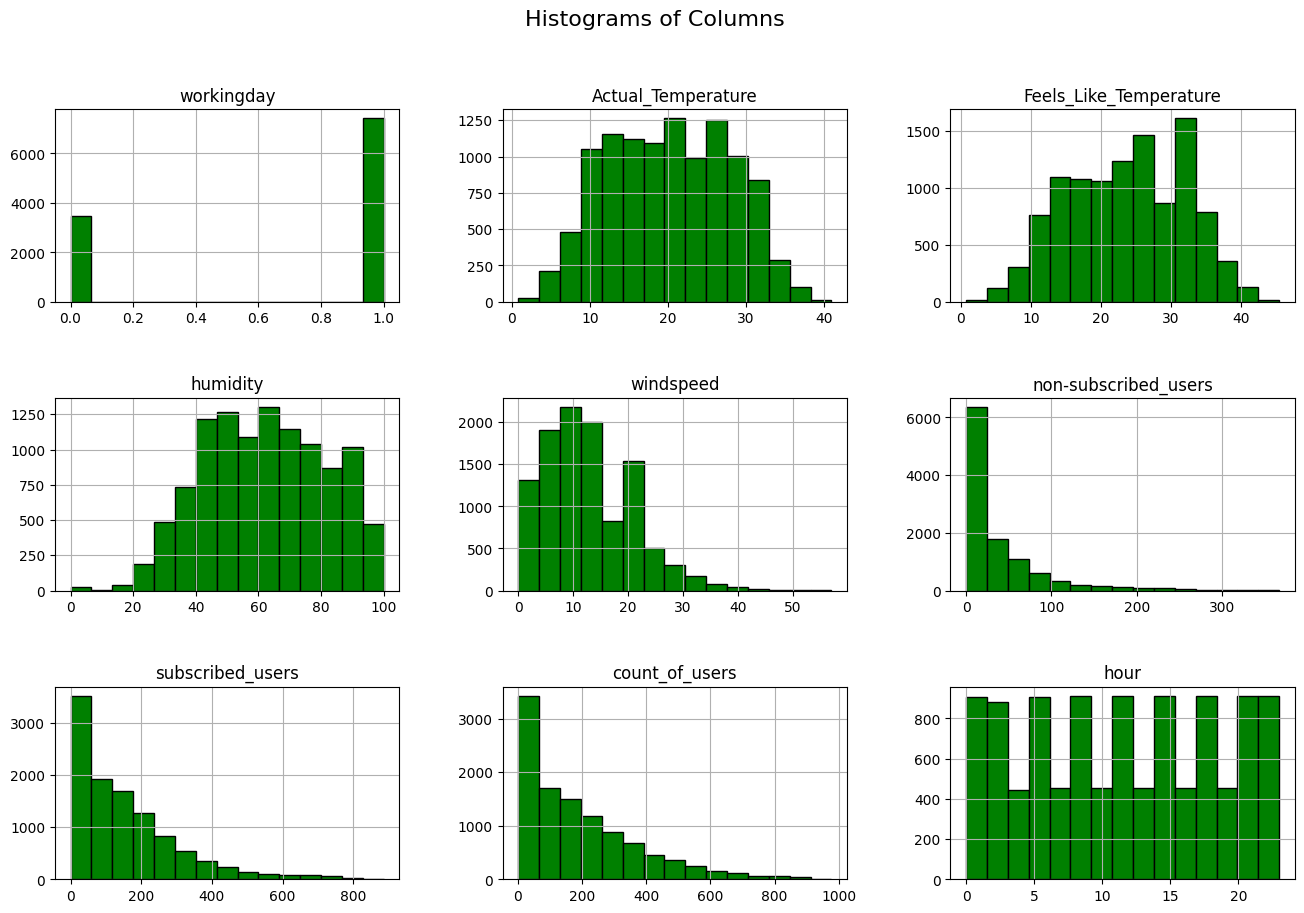

In [136]:
df.select_dtypes('number').hist(bins=15, figsize=(16, 10), color='green', edgecolor='black')

plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5) 
plt.show()

- ### **Correlation**

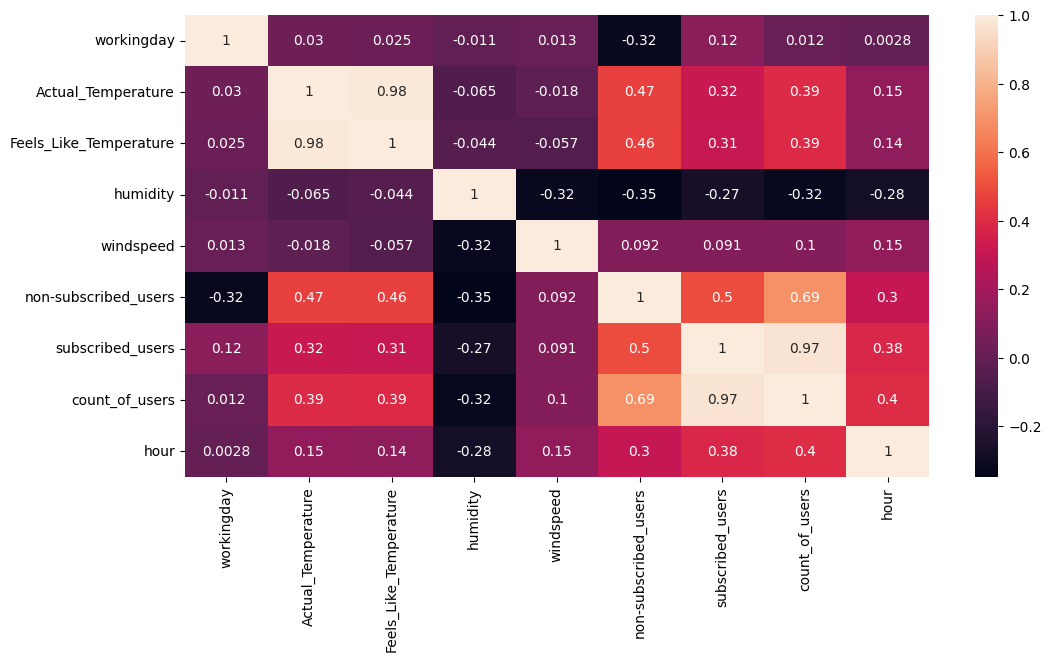

In [137]:
plt.figure(figsize=(12,	6))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)
plt.show()

#### **1. Customer Types and Pricing Plan (User Types vs. Working Days)**
##### There is a moderate negative correlation (-0.32) between working days and non-subscribe users, compared to a positive correlation (0.12) with subscribes users.

##### Business Interpretation : Members rely on bicycles as a primary and economical means of transportation to work and university. non-subscribe users (tourists and leisure travelers) avoid the financially draining traffic of workdays (based on hourly rates) and prefer recreational rentals on weekends and holidays.

#### **2. Weather Impact:**
##### Temperature is the biggest driver of occupancy rates, and its correlation with the non-subscribe users (0.47) is stronger than with the subscribe users (0.32).

##### Business Interpretation : The leisure user is very sensitive to weather conditions and will only rent during warm weather (spring and summer), while the subscribe users is obligated to stay even on cold days due to work requirements. A logical inverse correlation (-0.32) was also observed between humidity and wind speed.

#### **3. Hourly Demand Dynamics**
##### There is a general positive correlation (0.4) between the hours of the day and the number of users.

##### Business Interpretation : Demand is negligible in the early morning hours (1 to 5 AM) because most users are asleep, and it gradually increases as the day progresses. (The relationship here is non-linear and follows the morning and evening peak demand curves.)

- ### **Count of users Distribution**

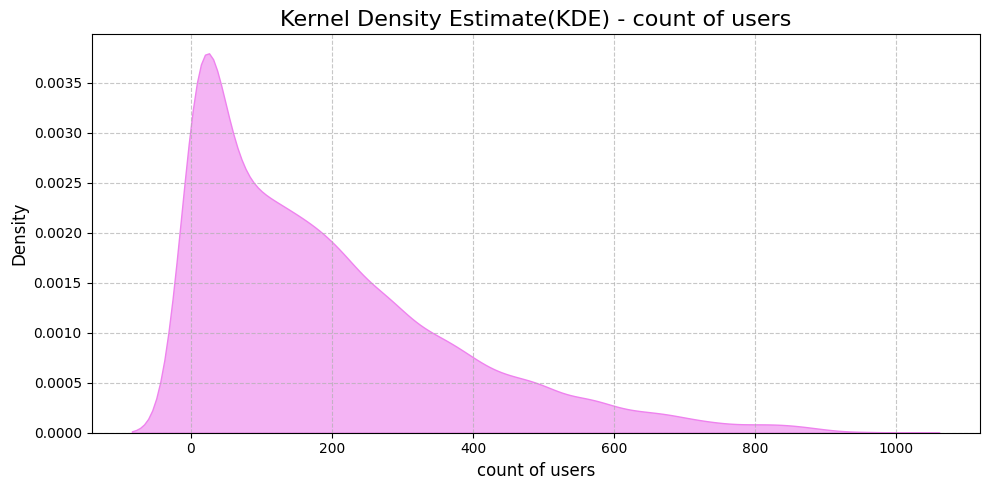

In [138]:
plt.figure(figsize=(10,	5))
sns.kdeplot(df['count_of_users'], fill=True,	color='violet', alpha=0.6)
plt.title(f'Kernel Density Estimate(KDE) - count of users',	fontsize=16)
plt.xlabel('count of users', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### This distribution tells us that our business is generally stable at low to medium rates most of the time (the large pink block on the left), but we do have 'explosive peak seasons' (the long tail extending to the right towards 600 and 800 users). These peaks don't always occur, but when they do, they pull the company's overall average up.


- ### **boxplot of count of users**


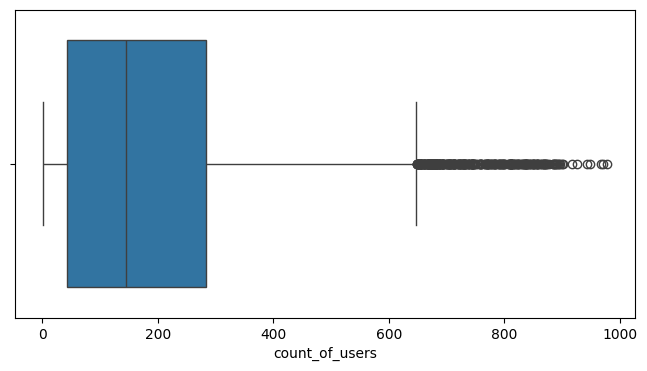

In [139]:
boxplot(df,'count_of_users')


- ### **boxplot of count of users vs categorical features**


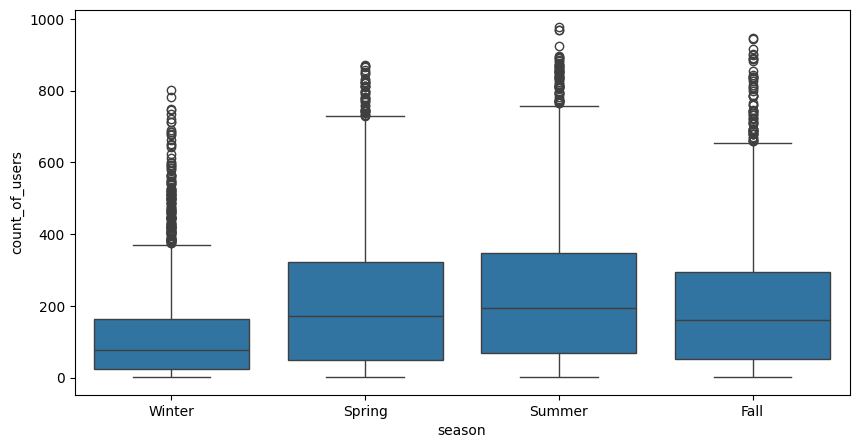

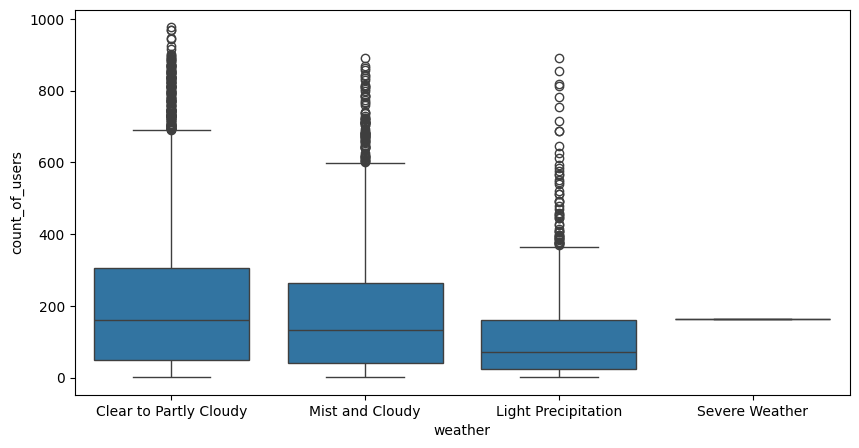

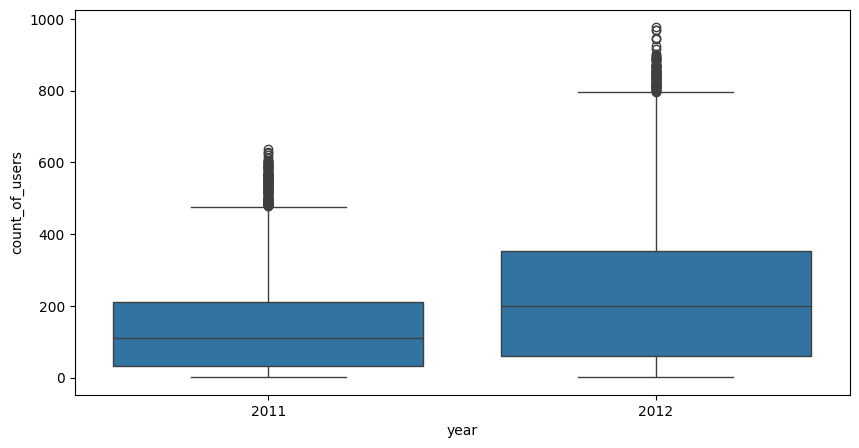

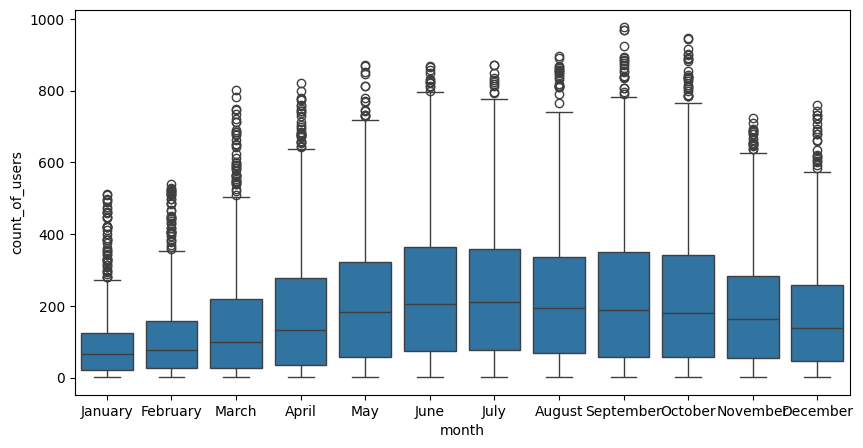

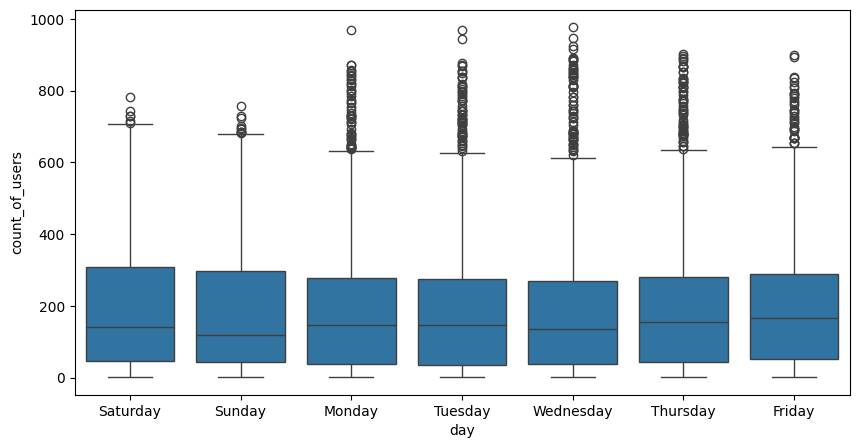

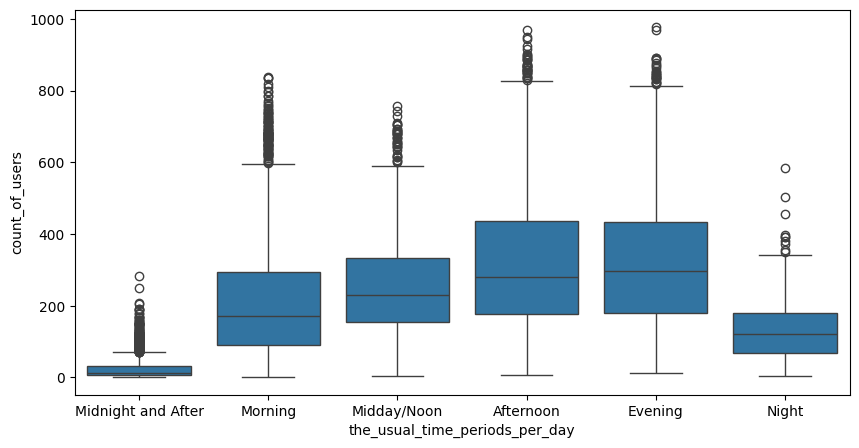

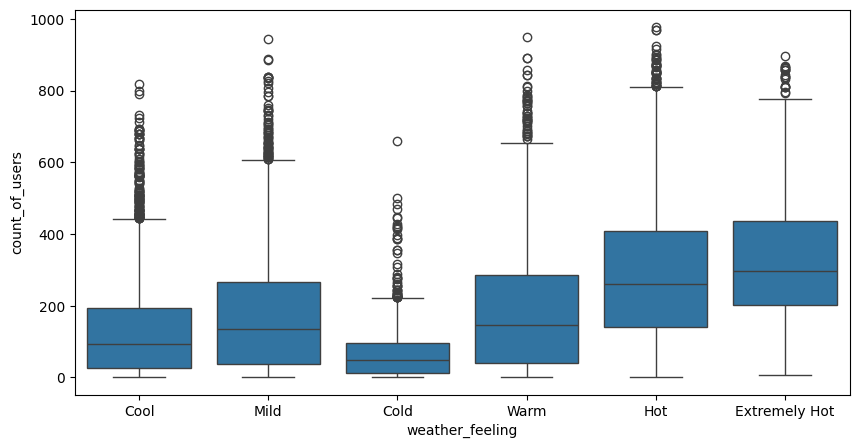

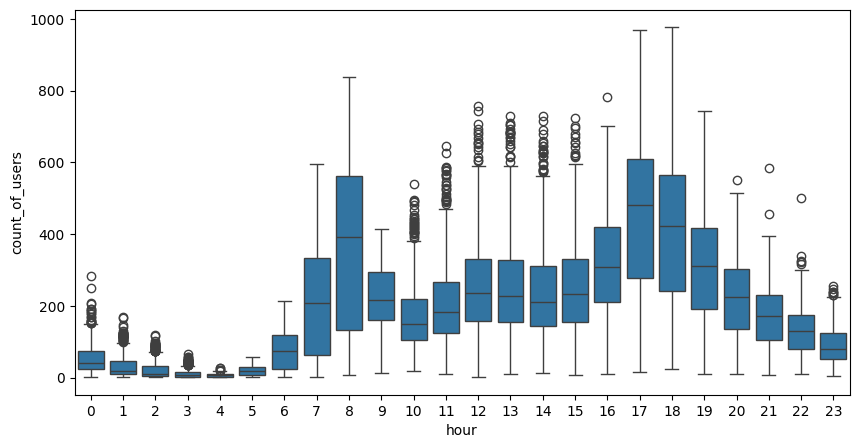

In [140]:
colscat = ['season','weather','year', 'month', 'day', 'the_usual_time_periods_per_day', 'weather_feeling','hour']
for col in colscat:
    boxplot2(df,col,'count_of_users')

-----------------------

In [141]:
# df.to_excel('Bake rental (New data).xlsx',index=False)

--------------------------------
------------------------------

## **Hypothesis Testing Analysis**

--------------------------------

In [142]:
df['log count of users'] = np.log1p(df['count_of_users'])

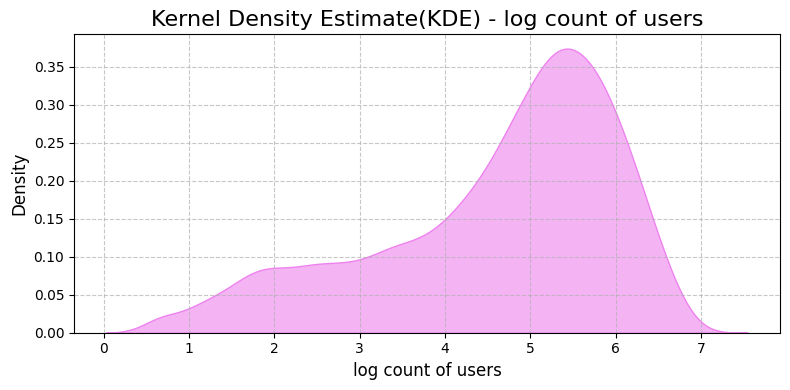

In [143]:
plt.figure(figsize=(8,	4))
sns.kdeplot(df['log count of users'], fill=True,	color='violet', alpha=0.6)
plt.title(f'Kernel Density Estimate(KDE) - log count of users',	fontsize=16)
plt.xlabel('log count of users', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### The logarithm transformation revealed the true structure of tenant behavior. We don't have one pattern, but two completely separate patterns:

- ##### The large cluster (high peak at 5.5): This represents the normal operating hours (where 5.5 ≈ 244 users per hour), and this is the company's natural pulse throughout the day.

- ##### The extended tail and the leftward protrusions (between 1 and 3): These represent the hours of complete inactivity (2 ≈ only 7 users), which are the hours after midnight and at dawn (from 1 AM to 5 AM).

------------------------------
- #### **mean of count of users**
------------------------------

In [144]:
users_data = df['count_of_users']
mean = users_data.mean()
std = users_data.std()
n = len(users_data)

standard_error = std / np.sqrt(n)

confidence_level = 0.95
ci_lower, ci_upper = stats.t.interval(confidence_level, df=n-1, loc=mean, scale=standard_error)


print(f"Point Estimate: ${mean:.2f}")
print(f"Standard Error: {standard_error:.4f}")
print(f"Confidence Interval for 95 %: [${round(ci_lower)} , ${round(ci_upper)}]")


Point Estimate: $191.57
Standard Error: 1.7362
Confidence Interval for 95 %: [$188 , $195]


---------------------------------
- #### **holidays and working days vs count of users & non subscribed users**
---------------------------------- 

In [145]:
# count of users column is not normal distribution
workday_users = df[df['holiday'] == 'no']['count_of_users']
holiday_users = df[df['holiday'] == 'yes']['count_of_users']

stat, p_value = stats.mannwhitneyu(workday_users, holiday_users)

print(f"p-value: {p_value:.6f}")
if p_value < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

p-value: 0.864636
There is not a significant difference ---> H0 is not rejacted


In [146]:
non_sub_workday = df[df['holiday'] == 'no']['non-subscribed_users']
non_sub_holiday = df[df['holiday'] == 'yes']['non-subscribed_users']

stat_sub, p_value_sub = stats.mannwhitneyu(non_sub_workday, non_sub_holiday)
print(f"p-value : {p_value_sub:.6f}")

if p_value_sub < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

p-value : 0.003708
There is a significant difference ---> H0 is rejected


##### Looking only at the total number of users, we might mistakenly believe that holidays don't affect our count of users (p=0.86). However, after further analysis, we discovered that this apparent similarity is a statistical illusion. A very active segment during holidays is non-subscriber users, and our tests revealed a significant and noticeable difference in their behavior (p=0.0037).

##### Business Recommendation : Holidays see a massive influx of users (tourists and vacationers). We should raise our individual rental rates (per hour) on weekends to maximize profits and offer them a discount code at the end of the day to convert them into "regular subscribers" who will serve us during the week!

-----------------------------
- #### **season vs count of users**


In [147]:
fall = df[df['season']=='Fall']['count_of_users']
spring = df[df['season']=='Spring']['count_of_users']
summer = df[df['season']=='Summer']['count_of_users']
winter = df[df['season']=='Winter']['count_of_users']

In [148]:
def Shapiro(season):
    stat, p = stats.shapiro(season)

    print(f'Shapiro-Wilk Statistic: {stat:.4f}, P-value: {p:.4f}')
    
    if p > 0.05:
        print("The group follows a normal distribution (ANOVA)")
    else :
        print("The group does not follow the normal distribution (Kruskal-Wallis)")

In [149]:
season = [fall,spring,summer,winter]
for s in season:
    Shapiro(s)
    print('----------------------------------------------------')

Shapiro-Wilk Statistic: 0.8955, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)
----------------------------------------------------
Shapiro-Wilk Statistic: 0.9005, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)
----------------------------------------------------
Shapiro-Wilk Statistic: 0.9148, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)
----------------------------------------------------
Shapiro-Wilk Statistic: 0.8087, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)
----------------------------------------------------


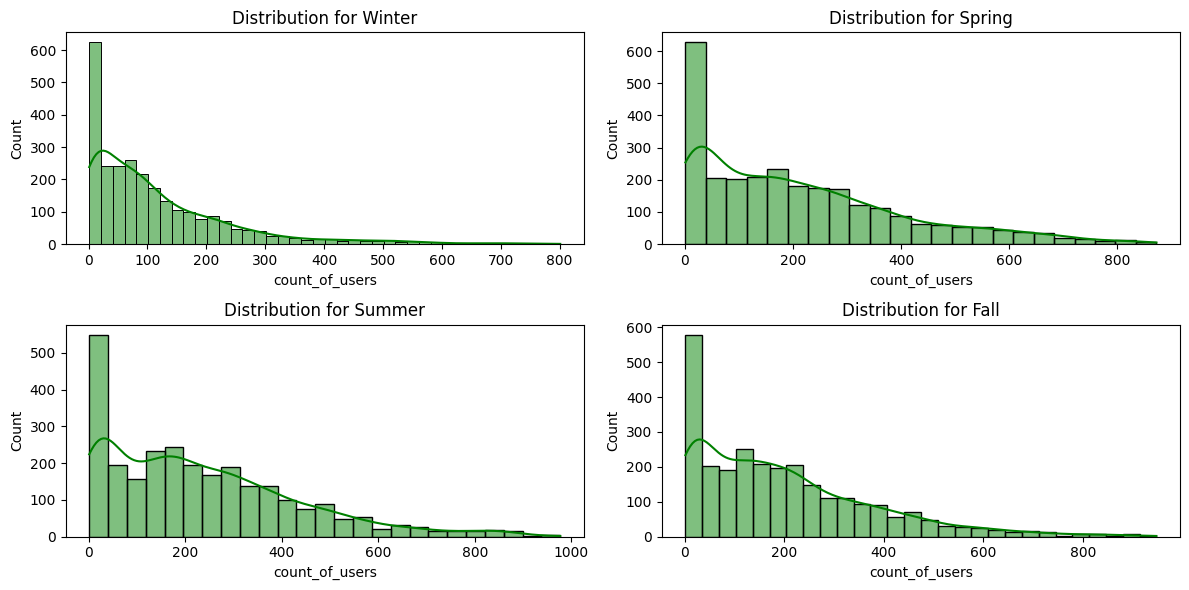

In [150]:
groups = df['season'].unique()

plt.figure(figsize=(12, 6))

for i, group in enumerate(groups):
    data_group = df[df['season'] == group]['count_of_users']
    
    plt.subplot(2, 2, i+1)
    sns.histplot(data_group, kde=True, color='green')
    plt.title(f'Distribution for {group}')

plt.tight_layout()
plt.show()

In [151]:
stat, p_value_k = stats.kruskal(fall, spring, summer, winter)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 699.6668548181915
P-value: 2.4790083726176776e-151
There is a significant difference


##### Weather seasons are not just names; they are the primary drivers of demand in our company. The differences between the seasons are real and scientifically proven, which necessitates that we completely abandon the idea of ​​a 'fixed budget year-round.'

##### Business recommendations based on the results:

- ##### Fleet Management: During peak seasons (which we will define in the next step, such as spring and summer), 100% of the bicycle fleet should be operational, and field maintenance teams should be intensified to redistribute bicycles among stations due to the surge in demand.

- ##### Dynamic Budgeting: Reduce advertising, marketing, and bicycle maintenance spending during off-peak seasons (winter and inclement weather), and free up these funds to be injected heavily a few weeks before the start of the peak season to attract the largest number of new customers.

- #### **day vs count of users**

In [152]:
Sunday = df[df['day']=='Sunday']['count_of_users']
Monday = df[df['day']=='Monday']['count_of_users']
Tuesday = df[df['day']=='Tuesday']['count_of_users']
Wednesday = df[df['day']=='Wednesday']['count_of_users']
Thursday = df[df['day']=='Thursday']['count_of_users']
Friday = df[df['day']=='Friday']['count_of_users']
Saturday = df[df['day']=='Saturday']['count_of_users']

In [153]:
stat, p_value_k = stats.kruskal(Sunday, Monday, Tuesday, Wednesday, Thursday, Friday, Saturday)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 18.30682858506734
P-value: 0.005509463320287259
There is a significant difference


##### Scientifically, the seven days of the week do not yield the same returns (p=0.0055). Operating activity and tenant behavior are reshaped daily throughout the week.

##### Business Recommendation : We suggest implementing a dynamic pricing strategy, whereby the hourly rental rate is automatically adjusted based on the day's pattern (e.g., preferential rates on off-peak days midweek to encourage occupancy, and higher operating rates on peak days like weekends to maximize profits).

- #### **Average Users Count By day Across season**

C:\Users\RPC\AppData\Local\Temp\ipykernel_18392\3352596220.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=dayAggregated["day"], y=dayAggregated["count_of_users"],hue=dayAggregated["season"], data=dayAggregated, join=True,ax=ax)


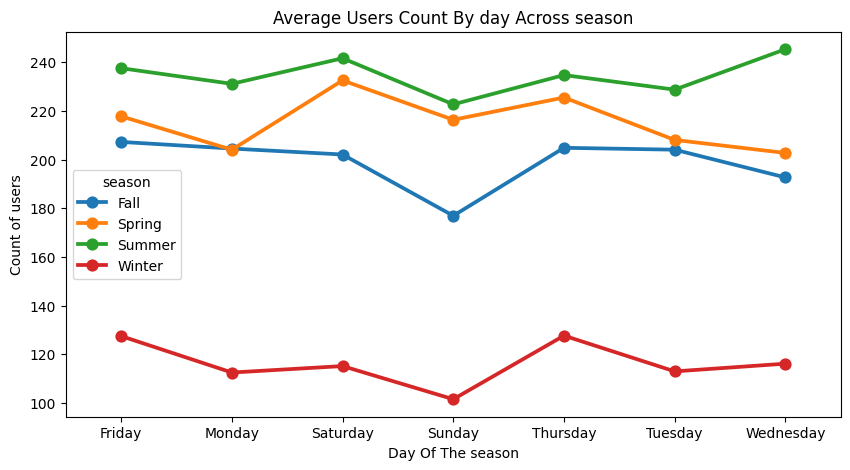

In [154]:
dayAggregated = pd.DataFrame(df.groupby(["season","day"],sort=True)["count_of_users"].mean()).reset_index()

fig,ax= plt.subplots()
fig.set_size_inches(10,5)
sns.pointplot(x=dayAggregated["day"], y=dayAggregated["count_of_users"],hue=dayAggregated["season"], data=dayAggregated, join=True,ax=ax)
ax.set(xlabel='Day Of The season', ylabel='Count of users',title="Average Users Count By day Across season",label='big')
plt.show()

##### The four seasons' lines are parallel, but they all undulate and descend on Sunday. This means that the "Sunday" effect has a different commercial weight if it is in the summer (when rents remain relatively high) compared to the winter (when it collapses completely close to 100).

- #### **Hours and season groub by mean of count of users**

C:\Users\RPC\AppData\Local\Temp\ipykernel_18392\1399915906.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["season"], data=hourAggregated, join=True,ax=ax)


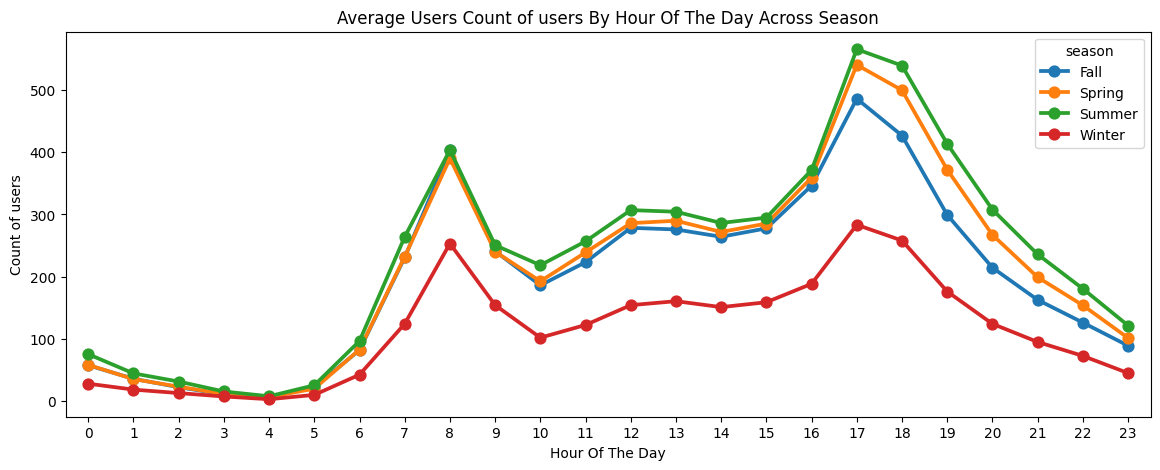

In [155]:
hourAggregated = pd.DataFrame(df.groupby(["hour","season"], sort=True)["count_of_users"].mean()).reset_index()

fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["season"], data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hour Of The Day', ylabel='Count of users',title="Average Users Count of users By Hour Of The Day Across Season",label='big')
plt.show()

##### Clear Daily and Seasonal Patterns : The plot clearly shows distinct daily cycles of user activity, with significant differences between seasons.

##### Two Peaks in User Activity : For most seasons, there appear to be two main peaks in user activity: one in the morning/late morning and another, more prominent, in the late afternoon/early evening.

##### Lowest Activity in Early Morning : User counts are consistently lowest across all seasons in the very early morning hours (approximately 1 AM to 5 AM).

- #### **Hours and day groub by mean of count of users**

C:\Users\RPC\AppData\Local\Temp\ipykernel_18392\3934328612.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["day"], data=hourAggregated, join=True,ax=ax)


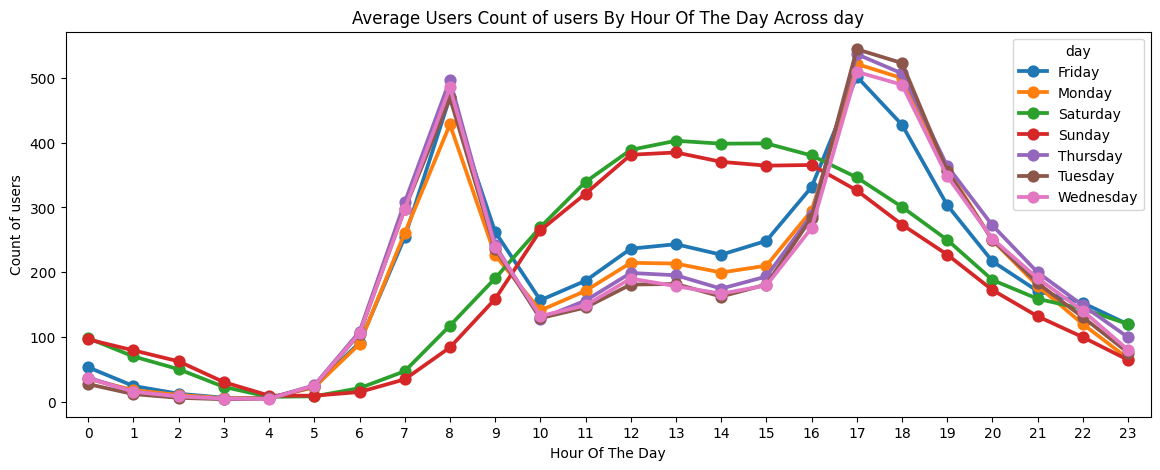

In [156]:
hourAggregated = pd.DataFrame(df.groupby(["hour","day"], sort=True)["count_of_users"].mean()).reset_index()

fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["day"], data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hour Of The Day', ylabel='Count of users',title="Average Users Count of users By Hour Of The Day Across day",label='big')
plt.show()

-------------------------
- #### **Regression Analysis**

In [157]:
import statsmodels.api as sm
scaler = StandardScaler()
X = df[['Actual_Temperature','humidity', 'windspeed']]
X[['Actual_Temperature','humidity', 'windspeed']] = scaler.fit_transform(X[['Actual_Temperature','humidity', 'windspeed']])
y = df['count_of_users']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         count_of_users   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     1154.
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        11:09:42   Log-Likelihood:                -70542.
No. Observations:               10886   AIC:                         1.411e+05
Df Residuals:                   10882   BIC:                         1.411e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                191.5741      1

C:\Users\RPC\AppData\Local\Temp\ipykernel_18392\3980034489.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['Actual_Temperature','humidity', 'windspeed']] = scaler.fit_transform(X[['Actual_Temperature','humidity', 'windspeed']])


-----------------------------------
## **Important Features**
-----------------------------------

##### Human movement follows a double bell curve (explosion in the morning when going to work, and in the evening when returning).

C:\Users\RPC\AppData\Local\Temp\ipykernel_18392\3409326351.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["workingday"], data=hourAggregated, join=True,ax=ax)


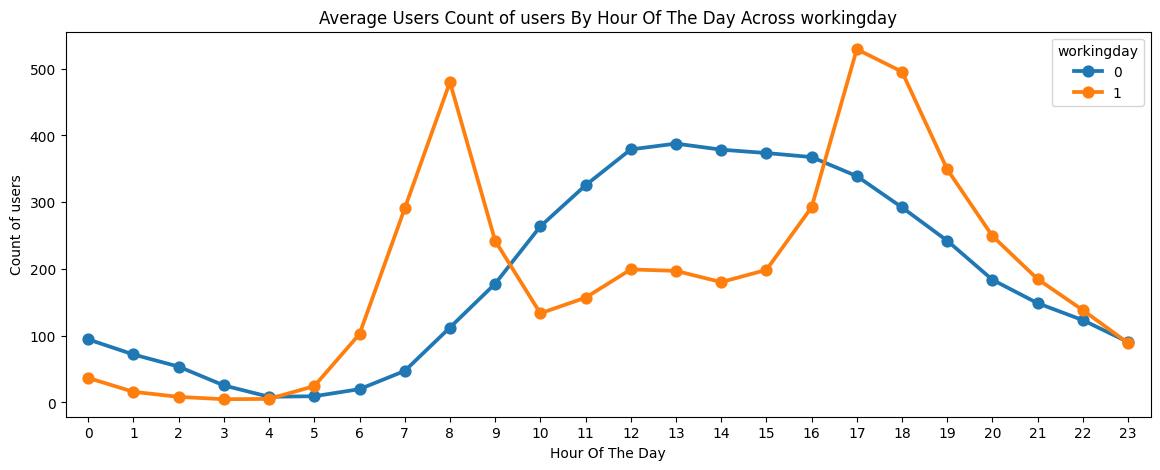

In [158]:
hourAggregated = pd.DataFrame(df.groupby(["hour","workingday"], sort=True)["count_of_users"].mean()).reset_index()

fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["workingday"], data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hour Of The Day', ylabel='Count of users',title="Average Users Count of users By Hour Of The Day Across workingday",label='big')
plt.show()

In [159]:
workday_peaks = [7, 8, 9, 16, 17, 18, 19]
df['is_workday_peak'] = ((df['workingday'] == 1) & (df['hour'].isin(workday_peaks))).astype(int)

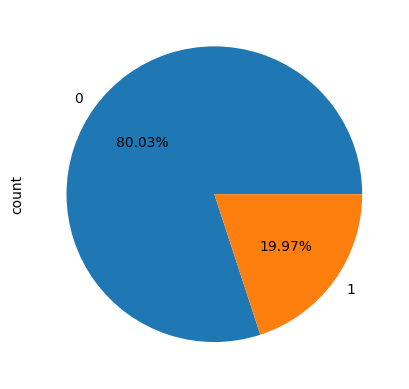

In [163]:
pie(df,'is_workday_peak')

In [160]:
weekend_peaks = [10,11, 12, 13, 14, 15, 16, 17, 18]
df['is_weekend_peak'] = ((df['workingday'] == 0) & (df['hour'].isin(weekend_peaks))).astype(int)

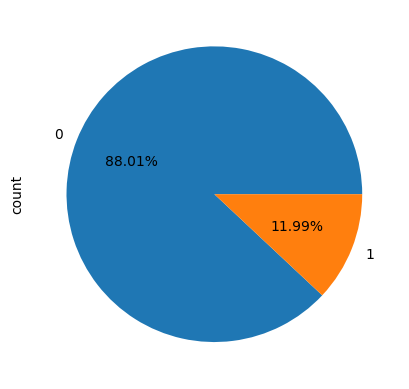

In [164]:
pie(df,'is_weekend_peak')

---------------------------------
--------------------------------

## **Machine Learning model**

-----------------------

In [168]:
df2 = df[['season', 'holiday', 'workingday', 'weather',
       'Actual_Temperature', 'humidity', 'windspeed',
       'count_of_users', 'month', 'day', 'hour',
       'the_usual_time_periods_per_day', 'weather_feeling',
       'is_workday_peak', 'is_weekend_peak']]

In [169]:
x = df2.drop('count_of_users',axis=1)
y = df2['count_of_users']
y_log = np.log1p(df['count_of_users'])

In [170]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.85,random_state=1234)
print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_test : {x_test.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_test : {y_test.shape}')

shape of x_train : (9253, 14)
shape of x_test : (1633, 14)
-------------------------------
shape of y_train : (9253,)
shape of y_test : (1633,)


In [177]:
RandomForestRegressor_model = RandomForestRegressor()
XGBRegressor_model = XGBRegressor()
LGBMRegressor_model	= LGBMRegressor()
CatBoostRegressor_model = CatBoostRegressor()

In [182]:
ordered_categories = [
                        ['Winter', 'Spring', 'Summer', 'Fall'],             
                        ['no','yes'],
                        ['Clear to Partly Cloudy','Mist and Cloudy','Light Precipitation','Severe Weather'],
                        ['January','February','March','April','May','June','July','August','September','October','November','December'],
                        ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
                        ['Midnight and After', 'Morning', 'Midday/Noon', 'Afternoon', 'Evening', 'Night'],
                        ['Cold', 'Cool', 'Mild','Warm','Hot','Extremely Hot']]

ordinal_cols = ['season', 'holiday', 'weather','month', 'day', 'the_usual_time_periods_per_day', 'weather_feeling']
ordinal_Encoder_pipeline = Pipeline(steps=[("encoder", OrdinalEncoder(categories = ordered_categories, handle_unknown="use_encoded_value",unknown_value=-1))])


num_cols = ['Actual_Temperature','humidity','windspeed','hour',]
numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ("ord", ordinal_Encoder_pipeline, ordinal_cols)
        ])

In [184]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Actual_Temperature', 'humidity', 'windspeed',
                                  'hour']),
                                ('ord',
                                 Pipeline(steps=[('encoder',
                                                  OrdinalEncoder(categories=[['Winter',
                                                                              'Spring',
                                                                              'Summer',
                                                                              'Fall'],
                                                                             ['no',
                                                                              'yes'],
                                                                             ['Clear '
                                                                              'to '
                                                                              'Partly '
                                                                              'Cloudy',
                                                                              'Mist '
                                                                              'and '
                                                                              'Cloudy',
                                                                              'Light '
                                                                              'Precipitation',
                                                                              'Severe '
                                                                              'Weather'],
                                                                             ['January'...
                                                                              'Tuesday',
                                                                              'Wednesday',
                                                                              'Thursday',
                                                                              'Friday',
                                                                              'Saturday',
                                                                              'Sunday'],
                                                                             ['Midnight '
                                                                              'and '
                                                                              'After',
                                                                              'Morning',
                                                                              'Midday/Noon',
                                                                              'Afternoon',
                                                                              'Evening',
                                                                              'Night'],
                                                                             ['Cold',
                                                                              'Cool',
                                                                              'Mild',
                                                                              'Warm',
                                                                              'Hot',
                                                                              'Extremely '
                                                                              'Hot']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                               

In [185]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('RandomForestRegressor_model', RandomForestRegressor())])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('XGBRegressor_model', XGBRegressor())])

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('LGBM_model', LGBMRegressor(objective='regression'))])

cat_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('CatBoost_model', CatBoostRegressor(verbose=0))])

In [187]:
rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Actual_Temperature',
                                                   'humidity', 'windspeed',
                                                   'hour']),
                                                 ('ord',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder(categories=[['Winter',
                                                                                               'Spring',
                                                                                               'Summer',
                                                                                               'Fall'],
                                                                                              ['no',
                                                                                               'yes'],
                                                                                              ['Clear '
                                                                                               'to '
                                                                                               'Partly '
                                                                                               'Cloudy',
                                                                                               'Mist '
                                                                                               'and '
                                                                                               'Cloudy',
                                                                                               'Light '
                                                                                               'Precipitatio...
                                                                                               'Sunday'],
                                                                                              ['Midnight '
                                                                                               'and '
                                                                                               'After',
                                                                                               'Morning',
                                                                                               'Midday/Noon',
                                                                                               'Afternoon',
                                                                                               'Evening',
                                                                                               'Night'],
                                                                                              ['Cold',
                                                                                               'Cool',
                                                                                               'Mild',
                                                                                               'Warm',
                                                                                               'Hot',
                                                                                               'Extremely '
                                                                                               'Hot']],
                                                                                  handle_unknown='use_encoded_value',
                                      

In [ ]:
r_2=[]
rmse=[]
mae=[]

def reg(model):
    model.fit(x_train,y_train)
    pred = model.predict(x_test)

    R2 = r2_score(y_test,pred)
    RMSE = sqrt(mean_squared_error(y_test,pred))
    MAE = mean_absolute_error(y_test,pred)
    
    r_2.append(R2)
    rmse.append(RMSE)
    mae.append(MAE)

In [188]:
Algorithms = ['RandomForestRegressor','XGBRegressor','LGBM_model','CatBoost_model']

In [ ]:
reg(RandomForestRegressor_model)
reg(XGBRegressor_model)
reg(RandomForestRegressor_model)
reg(GradientBoostingRegressor_model)

In [ ]:
result = DataFrame({'Algorithms':Algorithms,'R2':r_2,'rmse':rmse,'mae':mae})
result

,Algorithms,R2,rmse,mae
0,LinearRegression,0.423930,114.747856,88.345058
1,XGBRegressor,0.945005,35.454235,23.519283
2,RandomForestRegressor,0.938743,37.418462,23.772932
3,GradientBoostingRegressor,0.839119,60.639992,42.937466


#### **XGBRegressor (Clearly the Best)**:

- ##### Achieves the highest (R-score : 0.945) and the lowest RMSE (35.45) and MAE (23.51).
- ##### This model is by far the most powerful when the data is on its original scale, demonstrating its superior ability to handle the complexities, non-linear relationships, and heteroscedasticity in the raw data.

#### **RandomForestRegressor (Very Strong, Close Second to XGBoost)**:

- ##### Comes in a very close second with a high (R-score : 0.9389) and low RMSE and MAE.
- ##### Excellent performance also, reinforcing that ensemble tree-based models are highly effective for this data in its original form.

#### **GradientBoostingRegressor (Good Performance)**:

- ##### Achieve good (R-score : 0.8699 and 0.839 respectively), but lag behind XGBoost and RandomForest.
- ##### Strong models, but not as efficient as the two leading models in handling the original data.

#### **LinearRegression (Significantly the Weakest):**

- ##### The worst by far (R-score : 0.423), with the highest RMSE (114.75) and MAE (88.34).
- ##### This poor performance confirms that the relationship in the original "number of subscribers" data is not sufficiently linear, and there's a strong problem of heteroscedasticity, making the Linear Regression model unsuitable for this data in its raw form. This strongly justifies why the logarithmic transformation was so crucial for Linear Regression's later improved performance.


---------------------------

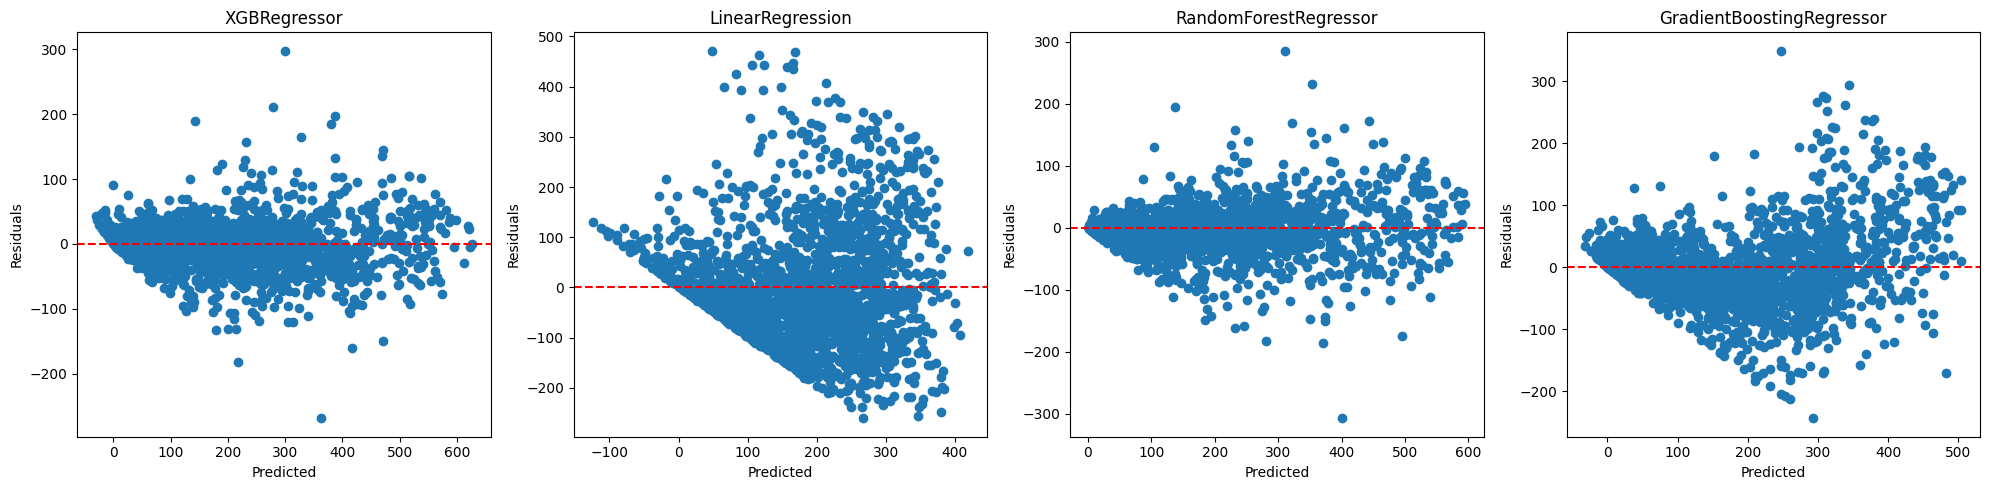

In [ ]:
fig, axes = subplots(1, 4, figsize=(20, 5))  

residuals_xgb = y_test - XGBRegressor_model.predict(x_test)
axes[0].scatter(XGBRegressor_model.predict(x_test), residuals_xgb)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("XGBRegressor")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_lr = y_test - LinearRegression_model.predict(x_test)
axes[1].scatter(LinearRegression_model.predict(x_test), residuals_lr)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("LinearRegression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

residuals_rf = y_test - RandomForestRegressor_model.predict(x_test)
axes[2].scatter(RandomForestRegressor_model.predict(x_test), residuals_rf)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title("RandomForestRegressor")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

residuals_gb = y_test - GradientBoostingRegressor_model.predict(x_test)
axes[3].scatter(GradientBoostingRegressor_model.predict(x_test), residuals_gb)
axes[3].axhline(y=0, color='red', linestyle='--')
axes[3].set_title("GradientBoostingRegressor")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("Residuals")

tight_layout()
show()

#### All presented regression models **(XGBRegressor, LinearRegression, RandomForestRegressor, GradientBoostingRegressor)** exhibit varying degrees of Heteroscedasticity (non-constant variance).

#### This phenomenon is particularly clear in the plots for **LinearRegression** and **GradientBoostingRegressor**, where the spread of prediction errors significantly increases as the predicted count of users grows.

#### **General Conclusion:**

#### The fundamental issue common across all models is that the variance of the prediction errors increases with a higher predicted count of users. This means the model (regardless of its type) is less accurate and less reliable when predicting larger numbers of subscribers compared to smaller numbers.

----------------------------------------
----------------------------------------

### **To improve the performance of all models, and specifically to address this issue of heteroscedasticity, a logarithmic transformation to count of users**

In [ ]:
y_transformed = log(y).replace(-inf,1e-6)

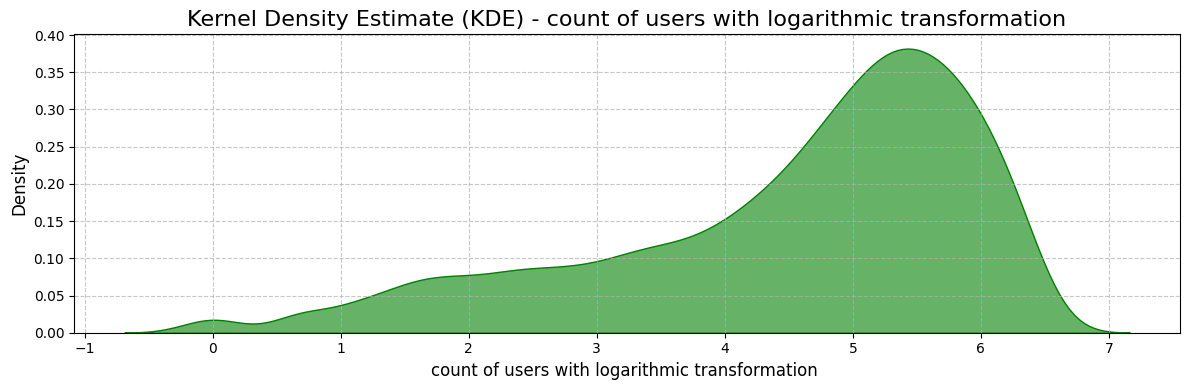

In [ ]:
figure(figsize=(12, 4))  
kdeplot(y_transformed, fill=True, color='green', alpha=0.6)  
title(f'Kernel Density Estimate (KDE) - count of users with logarithmic transformation', fontsize=16)  
xlabel('count of users with logarithmic transformation ', fontsize=12)  
ylabel('Density', fontsize=12) 
grid(True, linestyle='--', alpha=0.7)  
tight_layout()  
show()

#### **Shape of the Distribution:**

- ##### The distribution is now much closer to a normal (bell-shaped) distribution compared to what the original, untransformed "count of users" would likely have been (which would typically be heavily skewed to the right with a long tail).
- ##### It has a clear peak (mode) somewhere between 5 and 6 on the transformed scale.
- ##### There's still a slight left skew or a longer tail towards the lower values (left side of the peak), and a somewhat steeper drop-off on the right side. However, it's significantly less skewed than before.

#### **Impact of Logarithmic Transformation:**

- ##### The transformation has successfully compressed the higher values of "count of users" and stretched out the lower values. This is precisely what's needed to mitigate heteroscedasticity.
- ##### By making the distribution more symmetrical and less skewed, it's now more suitable for linear models and many other regression algorithms that often assume (or perform better with) normally distributed residuals and a more symmetrical target.

#### **No Negative Values (Implied):**

- ##### While the X-axis starts at -1, the density curve effectively starts from just above 0 on the transformed scale (which corresponds to 0 or very small positive values on the original scale if np.log1p was used). This is good, as actual subscriber counts cannot be negative.


--------------------------------

### **Spliting Data to train and test with y2**

In [ ]:
x_train, x_test, y2_train, y2_test = train_test_split(x, y_transformed, train_size=0.80, random_state=123)

-------------------------

## **Creating Model by using y2 as new target**

------------------------

In [ ]:
r_2=[]
rmse=[]
mae=[]

def reg2(model):
    model.fit(x_train,y2_train)
    pred2 = model.predict(x_test)

    R2 = r2_score(y2_test,pred2)
    RMSE = sqrt(mean_squared_error(y2_test,pred2))
    MAE = mean_absolute_error(y2_test,pred2)
    
    r_2.append(R2)
    rmse.append(RMSE)
    mae.append(MAE)

In [ ]:
LinearRegression_model2 = LinearRegression()
XGBRegressor_model2 = XGBRegressor()
RandomForestRegressor_model2 = RandomForestRegressor()
GradientBoostingRegressor_model2 = GradientBoostingRegressor()

In [ ]:
Algorithms2 = ['LinearRegression','XGBRegressor','RandomForestRegressor','GradientBoostingRegressor']

In [ ]:
reg2(LinearRegression_model2)
reg2(XGBRegressor_model2)
reg2(RandomForestRegressor_model2)
reg2(GradientBoostingRegressor_model2)

In [ ]:
result2 = DataFrame({'Algorithms2':Algorithms2,'R2':r_2,'rmse':rmse,'mae':mae})
result2

,Algorithms2,R2,rmse,mae
0,LinearRegression,0.489662,1.008304,0.771287
1,XGBRegressor,0.949483,0.317236,0.209764
2,RandomForestRegressor,0.945424,0.329733,0.214601
3,GradientBoostingRegressor,0.912578,0.417324,0.302136


#### **XGBRegressor (Best Performance):**

- ##### Achieves the highest R-score (0.94948) and the lowest RMSE (0.3172) and MAE (0.2097).
- ##### This model is clearly the best performer after the logarithmic transformation. Its ability to explain nearly 95% of the variance in the log-transformed target variable, coupled with the lowest errors, makes it the most accurate choice for this type of data.

#### **RandomForestRegressor (Very Strong, Second Place):**

- ##### Comes in a very close second to XGBRegressor (R-score : 0.94433) with very low RMSE (0.3330) and MAE (0.2160) values.
- ##### This model also demonstrates exceptional strength and robustness in prediction, making it an excellent alternative to XGBRegressor.

#### **DecisionTreeRegressor (Good Performance):**

- ##### Achieves a good R-score (0.91257), but with slightly higher RMSE (0.4173) and MAE (0.3021) values compared to the top two models.
- ##### As a foundational tree-based model, it delivers strong and reliable performance after the transformation.

#### **GradientBoostingRegressor (Good Performance):**
- ##### Its performance is good (R-score : 0.89264), with RMSE (0.4624) and MAE (0.2995) higher than DecisionTreeRegressor.
- ##### An effective model, but it lags behind the other models in this specific context.

#### **LinearRegression (Weakest Performance)**:

- ##### Shows the weakest performance among all models (R-score : 0.48966), with the highest RMSE (1.0083) and MAE (0.7712).
- ##### Despite the logarithmic transformation, this model remains the least effective in explaining variance and predicting the target variable in this case.

#### **Overall Summary:**

##### After the logarithmic transformation of the "number of subscribers" target variable, XGBRegressor and RandomForestRegressor clearly lead in performance. These models provide highly accurate and reliable predictions, making them the optimal choices for this data. Other models like DecisionTreeRegressor and GradientBoostingRegressor deliver good performance but are not at the same level as the top contenders. LinearRegression, in this context, is the least effective.

-----------------------------

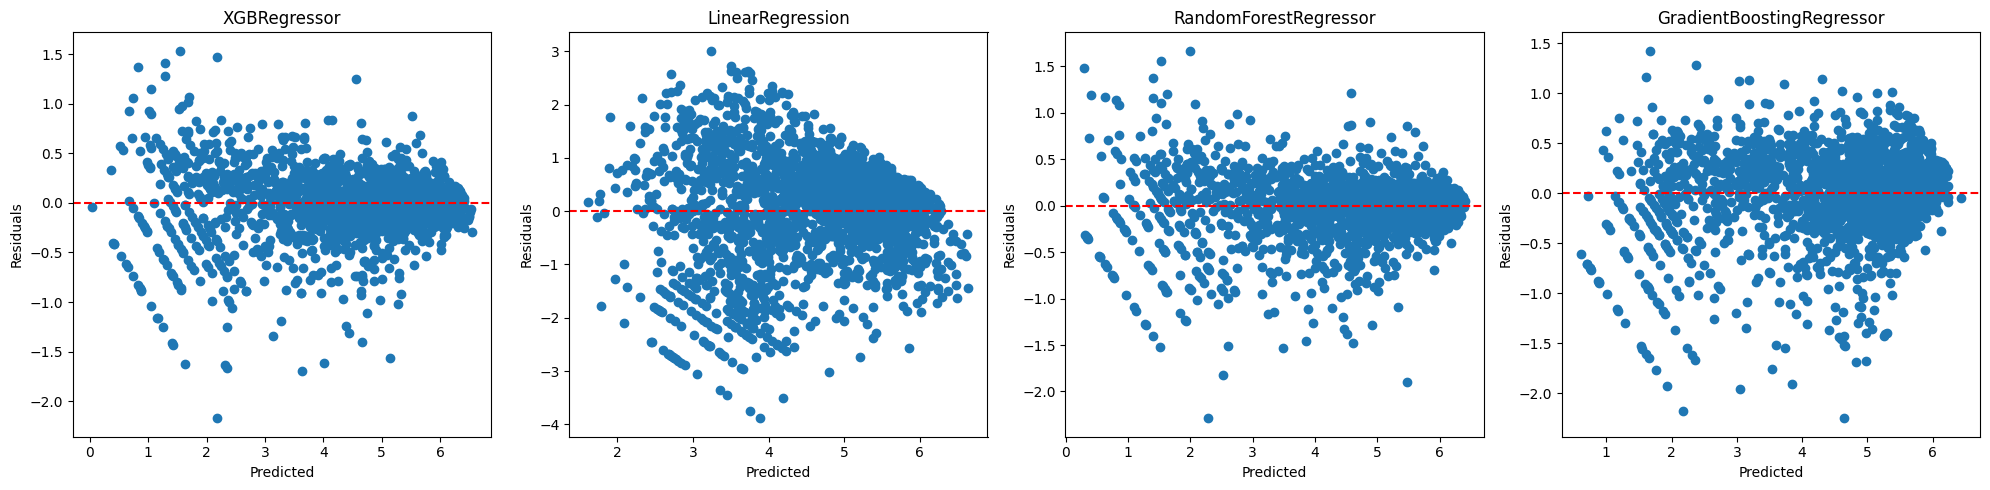

In [ ]:
fig, axes = subplots(1, 4, figsize=(20, 5))  

residuals_xgb = y2_test - XGBRegressor_model2.predict(x_test)
axes[0].scatter(XGBRegressor_model2.predict(x_test), residuals_xgb)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("XGBRegressor")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_lr = y2_test - LinearRegression_model2.predict(x_test)
axes[1].scatter(LinearRegression_model2.predict(x_test), residuals_lr)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("LinearRegression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

residuals_rf = y2_test - RandomForestRegressor_model2.predict(x_test)
axes[2].scatter(RandomForestRegressor_model2.predict(x_test), residuals_rf)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title("RandomForestRegressor")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

residuals_gb = y2_test - GradientBoostingRegressor_model2.predict(x_test)
axes[3].scatter(GradientBoostingRegressor_model2.predict(x_test), residuals_gb)
axes[3].axhline(y=0, color='red', linestyle='--')
axes[3].set_title("GradientBoostingRegressor")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("Residuals")

tight_layout()
show()

#### **XGBRegressor**:

- ##### **Scatter:** Points are well-scattered around the zero line (red dashed line).
- ##### **Homoscedasticity:** Despite the transformation, there's still a noticeable fanning out (heteroscedasticity) of the residuals as predicted values increase. This means the variance of the error increases with higher predicted subscriber counts (on the logarithmic scale).
- ##### **Bias:** There's a slight upward curve, indicating a minor tendency for underprediction at higher values.
- ##### Generally excellent performance, but the heteroscedasticity issue has not been fully resolved.

#### **LinearRegression**:

- ##### **Scatter**: Points are widely scattered and follow a clear curved pattern.
- ##### **Homoscedasticity**: Shows severe heteroscedasticity. The fanning out is very clear, as the spread of residuals significantly increases with higher predicted values.
- ##### **Bias:** There's a very strong curved pattern (non-linear relationship). Residuals are negative at lower predicted values (indicating overprediction) and become strongly positive at higher predicted values (indicating underprediction).
- ##### This model is clearly unsuitable for the data, even after logarithmic transformation. The non-linear relationship remains a major problem.

#### **RandomForestRegressor**:

- ##### **Scatter:** Similar to XGBRegressor, points are well-scattered around zero.
- ##### **Homoscedasticity**: Shows signs of heteroscedasticity similar to XGBRegressor, with the spread increasing at higher predicted values.
- ##### **Bias**: Residuals are generally centered around zero, with a slight upward trend at higher values.
- ##### Performance is very close to XGBRegressor, but with persistent heteroscedasticity.

#### **GradientBoostingRegressor**:

- ##### **Scatter**: Similar to RandomForest and XGBRegressor.
- ##### **Homoscedasticity**: Exhibits heteroscedasticity with the spread widening at higher predicted values.
- ##### **Bias**: There's a slight upward curve.
- ##### Its performance is good, but not as ideal as XGBRegressor or RandomForestRegressor in achieving homoscedasticity.

#### **General Summary of These Plots (Logarithmic Scale Residuals)**:

- ##### **Partial Success of Log Transformation**: The logarithmic transformation has partially fulfilled its role: it succeeded in bringing the errors within a more manageable range (the Y-axis is now within a reasonable scale), which contributed to the improved R-score values we saw previously.
- ##### **Persistent Heteroscedasticity**: However, all models, including the best performers (XGBRegressor and RandomForestRegressor), still exhibit noticeable heteroscedasticity (fanning out of residuals). This means that the model's accuracy varies depending on the magnitude of the prediction; it is less precise (or more variable) for larger predicted subscriber counts.
- ##### **LinearRegression is Unsuitable**: The strong pattern in LinearRegression's residuals confirms that it is an unsuitable model for this data, even after logarithmic transformation.
- ##### **Focus on Tree Models**: XGBRegressor and RandomForestRegressor remain the best choices as their residuals are closest to a random scatter, despite the persistent heteroscedasticity.

-------------------------------
-------------------------------
### **Testing Model**
-------------------------------

In [ ]:
with open('XGBRegressor_model2.pkl' , 'wb') as f :
     dump(XGBRegressor_model2, f)

In [ ]:
with open('XGBRegressor_model2.pkl','rb') as f : 
    XGBRegressor_model2 = load(f)

In [ ]:
y_predict = XGBRegressor_model2.predict(x_test)

In [ ]:
Importance = XGBRegressor_model2.feature_importances_
indices = argsort(Importance)[::-1]

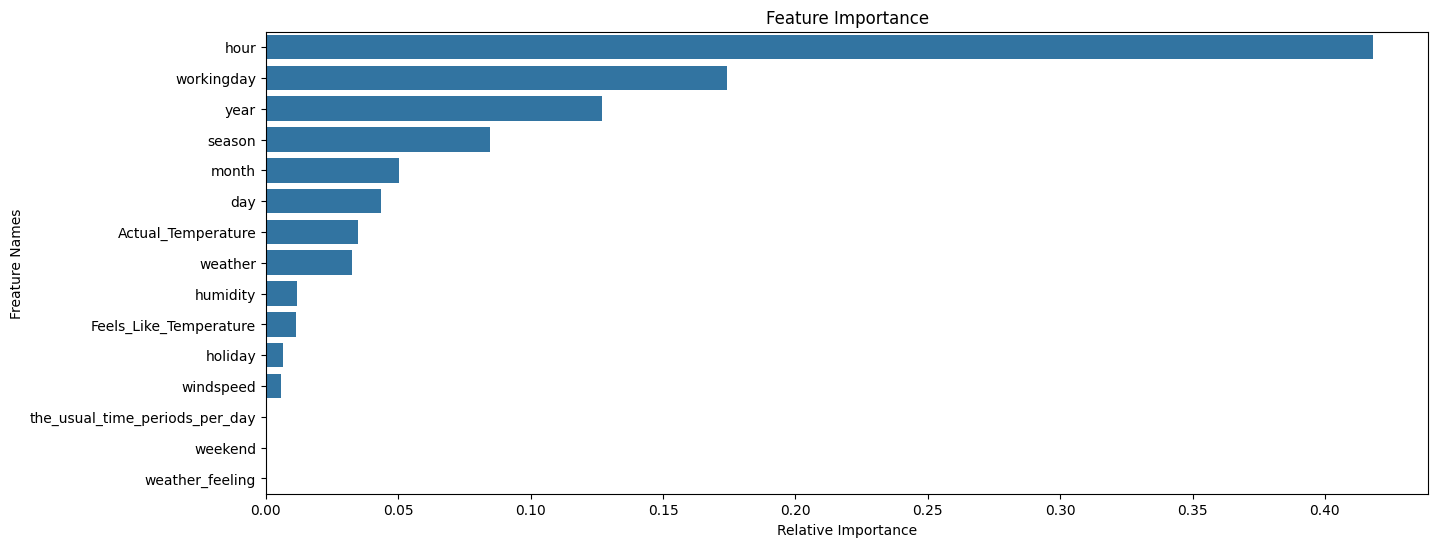

In [ ]:
figure(figsize=(15, 6))
barplot(x = Importance[indices], y = x.columns[indices])
title('Feature Importance')
xlabel('Relative Importance')
ylabel('Freature Names')
show()

In [ ]:
new_data_test = read_excel('data for test.xlsx')

In [ ]:
original_new_data_test = new_data_test.copy()

In [ ]:
new_data_test = new_data_test[['holiday', 'workingday', 'Actual_Temperature', 'Feels_Like_Temperature',
       'humidity', 'windspeed', 'count_of_users', 'year', 'hour', 'season',
       'weather', 'month', 'day', 'weekend', 'the_usual_time_periods_per_day',
       'weather_feeling']]

In [ ]:
new_data_test = new_data_test.drop('count_of_users', axis=1)

In [ ]:
new_data_test['year'] = new_data_test['year'].astype(int)

new_data_test['weekend'] = new_data_test['weekend'].map({'No':0, 'Weekend':1})
new_data_test['weather']= new_data_test['weather'].map({'Clear to Partly Cloudy':0,'Mist and Cloudy':1,'Light Precipitation':2,'Severe Weather':3})
new_data_test['weather_feeling']= new_data_test['weather_feeling'].map({'Cold':0, 'Cool':1, 'Mild':2,'Warm':3,'Hot':4,'Extremely Hot':5})
new_data_test['month']= new_data_test['month'].map({'January':1, 'February':2,'March':3,'April':4, 'May':5, 'June':6, 'July':7,
                                                'August':8, 'September':9, 'October':10, 'November':11, 'December':12})
new_data_test['day']= new_data_test['day'].map({'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6})
new_data_test['season']= new_data_test['season'].map({'Winter':0, 'Spring':1, 'Summer':2, 'Fall':3})
new_data_test['the_usual_time_periods_per_day']= new_data_test['the_usual_time_periods_per_day'].map({'Midnight and After':0, 'Morning':1,
                            'Midday/Noon':2, 'Afternoon':3, 'Evening':4, 'Night':5})


In [ ]:
new_predictions = XGBRegressor_model2.predict(new_data_test)

In [ ]:
new_predictions = exp(new_predictions) 

In [ ]:
original_new_data_test['Count Of Users Predicted'] = new_predictions

In [ ]:
original_new_data_test['Count Of Users Predicted'] = original_new_data_test['Count Of Users Predicted'].apply(lambda x : round(x))

In [ ]:
original_new_data_test.to_excel("bike rental test data prediction.xlsx", index=False)

In [ ]:
pred_data = read_excel('bike rental test data prediction.xlsx')
pred_data[['count_of_users','Count Of Users Predicted']].head(4)

,count_of_users,Count Of Users Predicted
0,37,30
1,36,38
2,34,39
3,28,26


--------------------------------
--------------------------------
# <center><strong>Conclusion</strong></center>
--------------------------------------------------

#### **It follows a clear workflow — starting from data importation, exploratory data analysis (EDA) with visual and statistical insights, through data cleaning and feature relationship exploration, to model training with techniques such as Linear Regression, XGBoost, and Random Forest. The project reflects a solid understanding of data analysis principles and model evaluation using metrics like R², RMSE, and MAE. Overall, the results highlight the models’ ability to produce reasonably accurate predictions after proper data preprocessing, making this project an excellent practical application of data science in smart transportation and urban resource management.**
----------------------------

In [ ]:
# !jupyter nbconvert --to html "Bike rental Prediction_project.ipynb"

[NbConvertApp] Converting notebook Bike rental Prediction_project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 39 image(s).
[NbConvertApp] Writing 3617663 bytes to Bike rental Prediction_project.html
